# Bitcoin Analytics Capstone — Exploratory Data Analysis

**Focus:** Evaluating Prediction Market Activity as Regime-Level Signals for Bitcoin Accumulation  
**Data Sources:** Coin Metrics & Polymarket (Sponsor-Provided)

This notebook presents a narrative-driven exploratory analysis examining whether liquidity-filtered prediction market activity provides information orthogonal to traditional Bitcoin market and on-chain metrics. The goal is not price prediction, but to assess whether such signals can serve as contextual inputs for dynamic, long-only accumulation modeling.


## 1. Data Retrieval

All datasets used in this exploratory analysis were obtained using the official data retrieval script provided by the project sponsor:

https://github.com/TrilemmaFoundation/bitcoin-analytics-capstone-template/blob/main/data/download_data.py

The script was executed from the repository root. It downloads the sponsor-managed Google Drive folder and organizes all approved files into a local `data/` directory while preserving the original subfolder structure. Only supported file types (`.parquet`, `.csv`, `.md`) are retained to ensure reproducibility and consistency with the sponsor template.

To keep this notebook lightweight, deterministic, and compliant with the official workflow, we do not re-run the download step here. Instead, we assume the data have already been retrieved once using the official pipeline and proceed by verifying the expected local directory structure before conducting exploratory analysis.


In [1]:
import os
from pathlib import Path

# ---- Automatically detect repository root ----
REPO_ROOT = Path.cwd()

# If notebook is inside a subfolder (e.g., EDA/ or deliverables/), move upward until data/ is found
if not (REPO_ROOT / "data").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "data").exists():
            REPO_ROOT = parent
            break

# Fallback to your local path if running outside the repo
if not (REPO_ROOT / "data").exists():
    REPO_ROOT = Path(r"C:\Users\chen5\Documents\bitcoin-analytics-capstone")

os.chdir(REPO_ROOT)

print("Current working directory:")
print(os.getcwd())

# ---- Define data path ----
DATA_DIR = REPO_ROOT / "data"
print("Data directory exists:", DATA_DIR.exists())

# ---- Dataset-specific paths ----
COINMETRICS_PATH = DATA_DIR / "Coin Metrics" / "coinmetrics_btc.csv"
POLYMARKET_DIR = DATA_DIR / "Polymarket"

print("Coin Metrics file exists:", COINMETRICS_PATH.exists())
print("Polymarket dir exists:", POLYMARKET_DIR.exists())


Current working directory:
C:\Users\chen5\Documents\bitcoin-analytics-capstone
Data directory exists: True
Coin Metrics file exists: True
Polymarket dir exists: True


In [2]:
from pathlib import Path

# ---- Automatically detect repository root ----
REPO_ROOT = Path.cwd()

# Move upward until the repository data/ directory is found
while not (REPO_ROOT / "data").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

# If still not found, raise a clear error
if not (REPO_ROOT / "data").exists():
    raise RuntimeError(
        "Could not locate the repository root containing the 'data/' directory. "
        "Please run this notebook from within the cloned repository."
    )

print("Repository root:", REPO_ROOT)

# ---- Define data path ----
DATA_DIR = REPO_ROOT / "data"
print("Data directory exists:", DATA_DIR.exists())

# ---- Dataset-specific paths ----
COINMETRICS_PATH = DATA_DIR / "Coin Metrics" / "coinmetrics_btc.csv"
POLYMARKET_DIR = DATA_DIR / "Polymarket"

print("Coin Metrics file exists:", COINMETRICS_PATH.exists())
print("Polymarket dir exists:", POLYMARKET_DIR.exists())

Repository root: C:\Users\chen5\Documents\bitcoin-analytics-capstone
Data directory exists: True
Coin Metrics file exists: True
Polymarket dir exists: True


## 2. General Dataset Overview

This section provides a high-level validation of the datasets used in this exploratory analysis. The goal is to confirm structural integrity, temporal coherence, and completeness before conducting cross-feature exploratory analysis.

Two sponsor-provided data sources are used:

- **Coin Metrics**: Daily Bitcoin market and on-chain metrics (UTC daily cadence)
- **Polymarket**: Prediction market markets metadata and odds history (high-frequency updates later aggregated to daily)

The emphasis here is on data integrity and time coverage, not feature engineering or predictive modeling.


### 2.1 Coin Metrics Validation

Bitcoin market and on-chain data are sourced from Coin Metrics. The dataset is reported at a daily cadence and spans the full history of Bitcoin across multiple market cycles.

At this stage, the objective is to validate:

- Time coverage and continuity (no missing calendar days)
- Basic structure (rows/columns)
- Sanity checks for key variables (value ranges, descriptive statistics)
- Descriptive correlation context among a small set of core metrics

These checks establish the baseline market structure against which any external signal (e.g., prediction market activity) must demonstrate incremental or orthogonal informational value.


In [3]:
import pandas as pd

btc_df = pd.read_csv(COINMETRICS_PATH)
btc_df["time"] = pd.to_datetime(btc_df["time"])

print(
    "Rows:", btc_df.shape[0],
    "| Columns:", btc_df.shape[1],
    "| Missing days:",
    len(
        pd.date_range(
            btc_df["time"].min(),
            btc_df["time"].max(),
            freq="D"
        ).difference(btc_df["time"])
    )
)


Rows: 6221 | Columns: 32 | Missing days: 0


**Key checks**

- The dataset contains daily observations with a continuous date index (no missing calendar days).
- Columns cover price, market capitalization, network activity, and exchange flows.

Note: While the date index is continuous, some individual metrics may contain missing values in early Bitcoin history. Summary statistics are computed column-wise after dropping NaNs.


In [3]:
btc_df[["PriceUSD", "TxCnt", "HashRate"]].describe().round(2)


,PriceUSD,TxCnt,HashRate
count,5659.00,6220.00,6.214000e+03
mean,19809.99,208414.23,1.514551e+08
std,29699.08,170293.82,2.634492e+08
min,0.05,0.00,0.000000e+00
25%,260.58,47152.50,6.284000e+01
50%,5728.35,224415.50,5.567322e+06
75%,28820.68,312607.50,1.652824e+08
max,124824.45,928131.00,1.305500e+09


**Bitcoin Price History (Log Scale)**

To establish long-horizon market context, we visualize Bitcoin’s full price history using a logarithmic scale. This highlights regime shifts while preserving early-period dynamics.


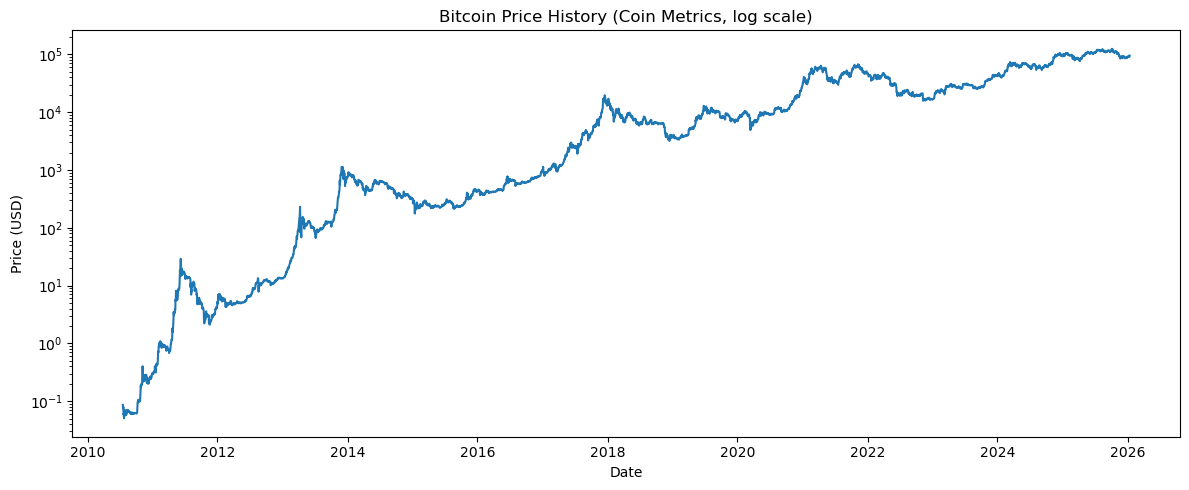

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(btc_df["time"], btc_df["PriceUSD"])
plt.yscale("log")
plt.title("Bitcoin Price History (Coin Metrics, log scale)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()


**High-Level Correlations Among Core Metrics**

As a final structural check, we examine correlations among a small set of core market and network variables. This step provides descriptive context rather than causal inference.


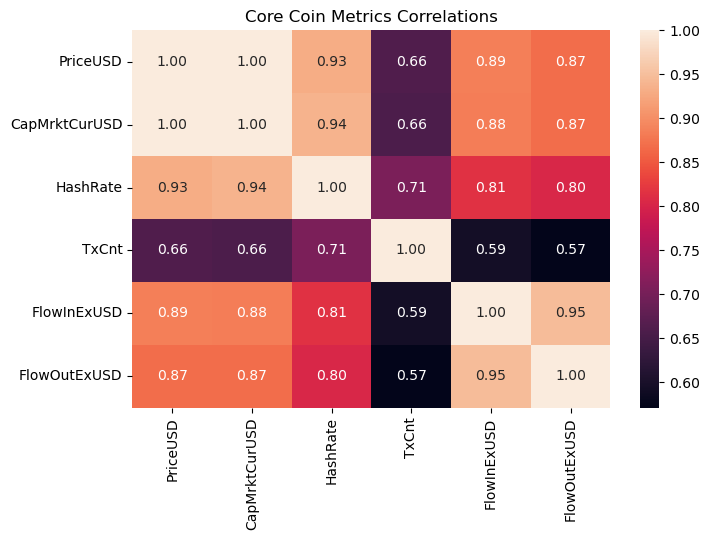

In [5]:
import seaborn as sns

core_cols = [
    "PriceUSD",
    "CapMrktCurUSD",
    "HashRate",
    "TxCnt",
    "FlowInExUSD",
    "FlowOutExUSD",
]
core_cols = [c for c in core_cols if c in btc_df.columns]

corr = btc_df[core_cols].dropna().corr()

plt.figure(figsize=(7.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Core Coin Metrics Correlations")
plt.tight_layout()
plt.show()


**Section takeaway**

The Coin Metrics dataset provides a complete, long-horizon view of Bitcoin’s market and on-chain behavior with consistent daily coverage. This establishes a reliable baseline against which prediction-market-derived signals can be evaluated in later sections.


### 2.2 Polymarket Validation

Polymarket provides trading activity and probability dynamics for prediction markets spanning finance and politics. In this project, it serves as a complementary information source reflecting market-implied beliefs and participant behavior around macro and Bitcoin-adjacent events.

The objective of this section is to validate:

- Dataset scale and structural integrity (markets table + odds history)
- Probability value sanity checks (prices within [0, 1])
- Timestamp integrity (critical to prevent silent look-ahead bias)
- Confirmed alignment with the sponsor’s updated official loader


In [6]:
pm_markets = pd.read_parquet(POLYMARKET_DIR / "finance_politics_markets.parquet")
pm_odds = pd.read_parquet(POLYMARKET_DIR / "finance_politics_odds_history.parquet")

pm_markets["created_at"] = pd.to_datetime(pm_markets["created_at"])
pm_markets["end_date"] = pd.to_datetime(pm_markets["end_date"])

print("Markets table:", pm_markets.shape)
print("Odds history table:", pm_odds.shape)


Markets table: (78321, 10)
Odds history table: (2143181, 4)


In [7]:
print("Unique markets:", pm_markets["market_id"].nunique())
print("Unique events:", pm_markets["event_slug"].nunique())

pm_odds[["price"]].describe()


Unique markets: 78321
Unique events: 44033


,price
count,2.143181e+06
mean,5.000062e-01
std,3.909961e-01
min,5.000000e-04
25%,6.750000e-02
50%,5.000000e-01
75%,9.325000e-01
max,1.000000e+00


**Timestamp Integrity: Independent Detection & Validation**

Initial direct inspection of the raw odds timestamps revealed an anomaly (dates appearing in 1970), which is inconsistent with Polymarket’s operational history and indicates a timestamp unit encoding issue.

Because timestamp integrity directly impacts temporal alignment and leakage safety, we explicitly validate and correct this issue before any aggregation.


In [8]:
print(
    "Raw odds time range:",
    pm_odds["timestamp"].min(),
    "→",
    pm_odds["timestamp"].max()
)


Raw odds time range: 1970-01-20 09:08:38.412000 → 1970-01-21 10:59:34.930000


In [12]:
# ---- Fix odds timestamps (epoch milliseconds) ----
ts_ms = pd.to_numeric(pm_odds["timestamp"], errors="coerce")

pm_odds["timestamp_fixed"] = pd.to_datetime(ts_ms, unit="ms", utc=True)
pm_odds["date"] = pm_odds["timestamp_fixed"].dt.date

print(
    "Fixed odds time range:",
    pm_odds["timestamp_fixed"].min(),
    "→",
    pm_odds["timestamp_fixed"].max()
)
print("Unique days:", pm_odds["date"].nunique())


Fixed odds time range: 2023-01-24 00:00:12+00:00 → 2026-01-05 01:02:10+00:00
Unique days: 1066


**Sponsor Loader Verification**

The project sponsor subsequently updated the official loader to automatically correct malformed timestamp units. We verify that the sponsor implementation produces identical temporal coverage, confirming that:

- The anomaly was correctly identified
- The correction logic is consistent with sponsor-approved utilities
- Downstream aggregation and alignment are leakage-safe


In [15]:
import sys
from pathlib import Path
import polars as pl

# ---- Detect repository root ----
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "data").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

# ---- Add repo root to Python path ----
sys.path.append(str(REPO_ROOT))

print("Repository root:", REPO_ROOT)

# ---- Import loader ----
from eda.eda_starter_template import load_polymarket_data

# ---- Define data path ----
POLYMARKET_DIR = REPO_ROOT / "data" / "Polymarket"

poly_data = load_polymarket_data(POLYMARKET_DIR)

official_odds = poly_data["odds"]

print(
    "Official loader time range:",
    official_odds["timestamp"].min(),
    "→",
    official_odds["timestamp"].max()
)

print(
    "Official unique days:",
    official_odds.select(
        pl.col("timestamp").dt.date().n_unique()
    ).item()
)

Repository root: C:\Users\chen5\Documents\bitcoin-analytics-capstone
Loading Polymarket data from C:\Users\chen5\Documents\bitcoin-analytics-capstone\data\Polymarket...
[Memory] Before loading Polymarket data: 460.36 MB
Loaded 78321 markets.
Loaded 2143181 odds history records.
Loaded 78321 summary records.
[Memory] After loading Polymarket data: 671.30 MB (Δ 210.95 MB)
Official loader time range: 2023-01-24 00:00:12 → 2026-01-05 01:02:10
Official unique days: 1066


**Odds Update Density (Daily)**

As a final validation step, we examine the daily density of odds updates. Dense and continuous activity supports aggregation to daily frequency without relying on sparse sampling.


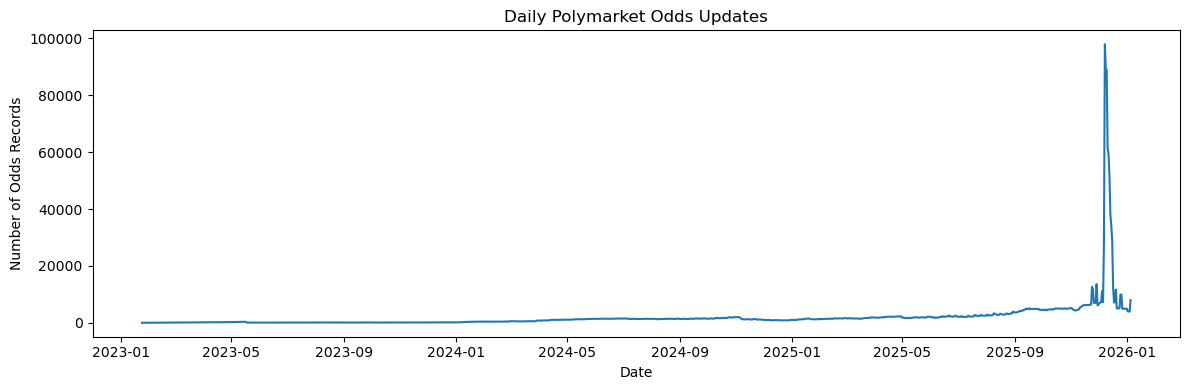

In [16]:
odds_daily = (
    pm_odds
    .groupby("date")
    .size()
)

plt.figure(figsize=(12, 4))
plt.plot(odds_daily.index, odds_daily.values)
plt.title("Daily Polymarket Odds Updates")
plt.xlabel("Date")
plt.ylabel("Number of Odds Records")
plt.tight_layout()
plt.show()


**Section takeaway**

The Polymarket dataset provides large-scale market coverage and well-formed probability values. After independent anomaly detection and cross-verification with the sponsor’s updated loader, timestamp integrity is confirmed.

The dataset can therefore be safely aggregated to daily frequency and aligned with Bitcoin market metrics without introducing temporal leakage.


## 3. Prediction Market Feature Construction

Having validated data integrity and temporal alignment, this section constructs daily prediction-market-derived features suitable for alignment with Bitcoin market data.

Raw Polymarket odds history contains over two million high-frequency updates across tens of thousands of markets with highly uneven liquidity. Direct aggregation across all markets would introduce substantial microstructure noise from thinly traded contracts.

Therefore, this section focuses on transforming raw odds history into stable, interpretable daily features using a liquidity-based filtering approach.


### 3.1 Smart Money Filtering

Polymarket contains more than 78,000 markets with highly uneven trading activity. Many markets exhibit sparse updates and low liquidity, which can introduce noise when constructing daily aggregate signals.

To improve aggregation reliability, we apply a liquidity-based filtering strategy.

**Operational definition ("smart money")**

In this notebook, "smart money" refers to the highest-liquidity subset of markets, specifically the top 100 markets ranked by total trading volume. This designation is purely operational:

- High-liquidity markets exhibit denser price updates
- Daily aggregates are more stable
- Signals are less influenced by thin-market microstructure noise

This terminology does not imply verified investor sophistication; it is strictly a liquidity-based filtering convention.

From this filtered subset, we construct three daily features:

- **smart_odds_updates**: number of odds updates (attention / uncertainty proxy)
- **smart_mean_price**: average probability level (contextual signal)
- **smart_price_std**: dispersion of probabilities (belief divergence proxy)


In [17]:
# ---- Filter for Top 100 Liquid Markets ----
top_volume_ids = pm_markets.nlargest(100, "volume")["market_id"]

# Filter the odds history to include ONLY these markets
pm_odds_filtered = pm_odds[pm_odds["market_id"].isin(top_volume_ids)]

# ---- Refined Daily Aggregation ----
pm_daily_refined = (
    pm_odds_filtered
    .groupby("date")
    .agg(
        smart_odds_updates=("price", "size"),
        smart_mean_price=("price", "mean"),
        smart_price_std=("price", "std")
    )
    .reset_index()
)

print("Refined Daily Features (Top 100 Markets):")
print(pm_daily_refined.head())
print("Shape:", pm_daily_refined.shape)


Refined Daily Features (Top 100 Markets):
         date  smart_odds_updates  smart_mean_price  smart_price_std
0  2024-01-05                  10               0.5         0.000000
1  2024-01-06                  18               0.5         0.423033
2  2024-01-07                  22               0.5         0.441671
3  2024-01-08                  22               0.5         0.445177
4  2024-01-09                  22               0.5         0.445677
Shape: (732, 4)


Across most days, the average probability level remains close to 0.5 due to the binary-outcome structure of prediction markets and cross-market averaging effects.

Accordingly:

- Mean price levels are treated as contextual signals
- Activity and dispersion features are emphasized for downstream analysis

The resulting dataset provides stable daily coverage suitable for alignment with Bitcoin metrics.


### 3.2 Daily Alignment with Bitcoin Data

To enable cross-feature exploratory analysis, the refined Polymarket features are aligned with daily Bitcoin market and on-chain metrics.

Alignment is performed using an inner join on calendar dates to ensure that:

- All observations correspond to days with both Bitcoin data and prediction market activity
- No implicit forward-looking information is introduced

This aligned dataset forms the primary table used in subsequent exploratory analysis.


In [18]:
# ---- Prepare daily Bitcoin table ----
btc_daily = (
    btc_df
    .assign(date=btc_df["time"].dt.date)
    .set_index("date")
    .sort_index()
)

# ---- Align Refined Datasets ----
pm_daily_idx = pm_daily_refined.set_index("date").sort_index()

aligned_df = (
    btc_daily
    .join(pm_daily_idx, how="inner")
    .sort_index()
)

print("Aligned dataset shape:", aligned_df.shape)

# Fill NaN for days where top markets might not have updates
aligned_df = aligned_df.ffill()

aligned_df.head()


Aligned dataset shape: (732, 35)


,time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,...,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d,smart_odds_updates,smart_mean_price,smart_price_std
date,,,,,,,,,,,,,,,,,,,,,
2024-01-05,2024-01-05,813324.0,52185685.0,1.704516e+09,1.704516e+09,138.0,1.983754,8.648562e+11,8.648256e+11,117.053818,...,1.959067e+07,1.613480e+06,7.122922e+10,2.074230e+07,416347.0,1025361.0,1.458810e+10,10,0.5,0.000000
2024-01-06,2024-01-06,808917.0,52182777.0,1.704603e+09,1.704603e+09,140.0,1.972627,8.604213e+11,8.603906e+11,85.704167,...,1.959155e+07,1.608179e+06,7.062797e+10,2.074241e+07,389306.0,917220.0,6.247901e+09,18,0.5,0.423033
2024-01-07,2024-01-07,713381.0,52185360.0,1.704691e+09,1.704691e+09,118.0,1.968589,8.590081e+11,8.589834e+11,76.090663,...,1.959229e+07,1.607342e+06,7.047262e+10,2.074250e+07,348435.0,813606.0,7.431340e+09,22,0.5,0.441671
2024-01-08,2024-01-08,756849.0,52192671.0,1.704773e+09,1.704773e+09,123.0,2.105200,9.205077e+11,9.204798e+11,128.016504,...,1.959306e+07,1.612735e+06,7.576842e+10,2.074260e+07,409400.0,900572.0,1.854234e+10,22,0.5,0.445177
2024-01-09,2024-01-09,902934.0,52162780.0,1.704863e+09,1.704863e+09,152.0,2.061112,9.029703e+11,9.029346e+11,110.412549,...,1.959401e+07,1.618416e+06,7.458308e+10,2.074272e+07,470829.0,1065162.0,1.915526e+10,22,0.5,0.445677


The resulting aligned dataset contains daily observations covering the overlapping period between Bitcoin metrics and high-liquidity prediction market activity.

This table integrates:

- Bitcoin market and on-chain features
- Aggregated prediction market activity signals

and serves as the primary input for cross-feature exploratory analysis in the following section.


## 4. Cross-Feature Exploratory Analysis

This section evaluates whether prediction-market-derived signals provide meaningful information when analyzed alongside Bitcoin market and on-chain metrics.

The objective is not price prediction. Instead, the focus is on identifying whether prediction market activity can serve as a contextual conditioning signal for dynamic, long-only Bitcoin accumulation strategies.

We investigate three key aspects:

- Co-movement between prediction market activity and Bitcoin price regimes
- Statistical relationships and robustness checks
- Whether activity regimes align with accumulation efficiency conditions


### 4.1 Co-movement Visualization

To assess whether prediction market activity exhibits meaningful co-movement with Bitcoin market dynamics, we visualize Bitcoin price and high-liquidity prediction market activity using a dual-axis time series plot.

- Left axis: Bitcoin price (log scale)
- Right axis: smart_odds_updates (prediction market activity)

This visualization provides an intuitive view of regime-level relationships.


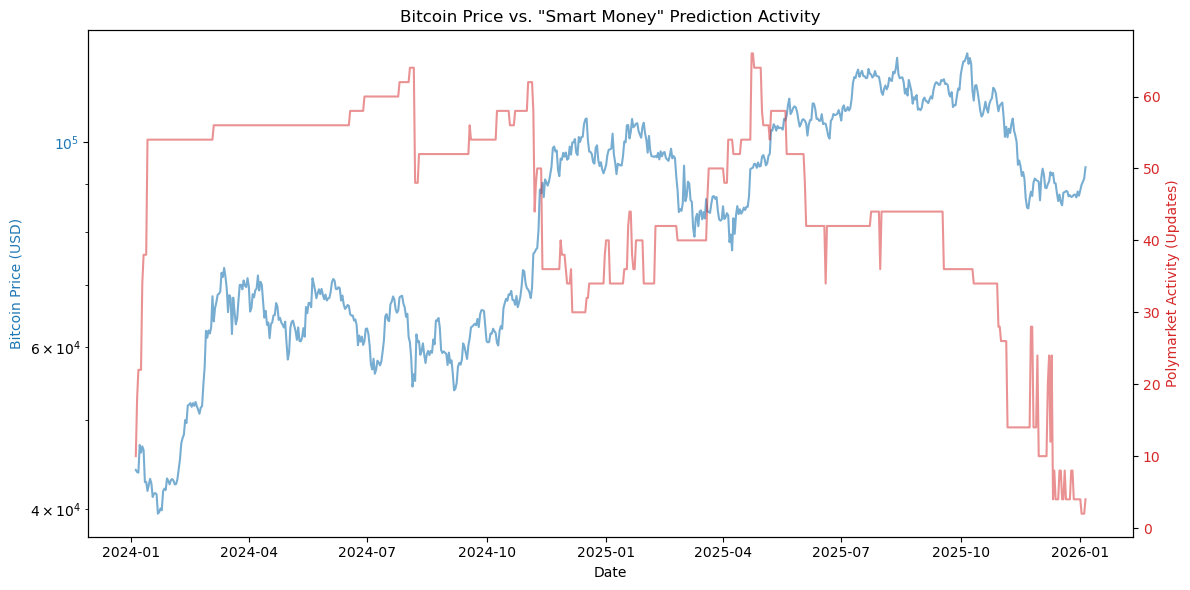

In [19]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# BTC price
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Bitcoin Price (USD)', color=color)
ax1.plot(
    aligned_df.index,
    aligned_df['PriceUSD'],
    color=color,
    alpha=0.6,
    label='BTC Price'
)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Prediction market activity
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Polymarket Activity (Updates)', color=color)
ax2.plot(
    aligned_df.index,
    aligned_df['smart_odds_updates'],
    color=color,
    alpha=0.5,
    label='Polymarket Activity'
)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Bitcoin Price vs. "Smart Money" Prediction Activity')
plt.tight_layout()
plt.show()


Periods of pronounced Bitcoin regime transitions are often accompanied by elevated prediction market activity.

Activity spikes tend to occur during major price movements or structural shifts, suggesting that participation intensity reflects market attention or uncertainty rather than short-term directional signals.

This observation motivates further statistical analysis of the relationship between activity and Bitcoin market conditions.


### 4.2 Correlation Structure & Robustness Checks

We examine statistical relationships between Bitcoin metrics and prediction market activity to determine whether these signals:

- Provide information beyond traditional market indicators
- Reflect short-term momentum or volatility
- Capture longer-horizon regime-level structure


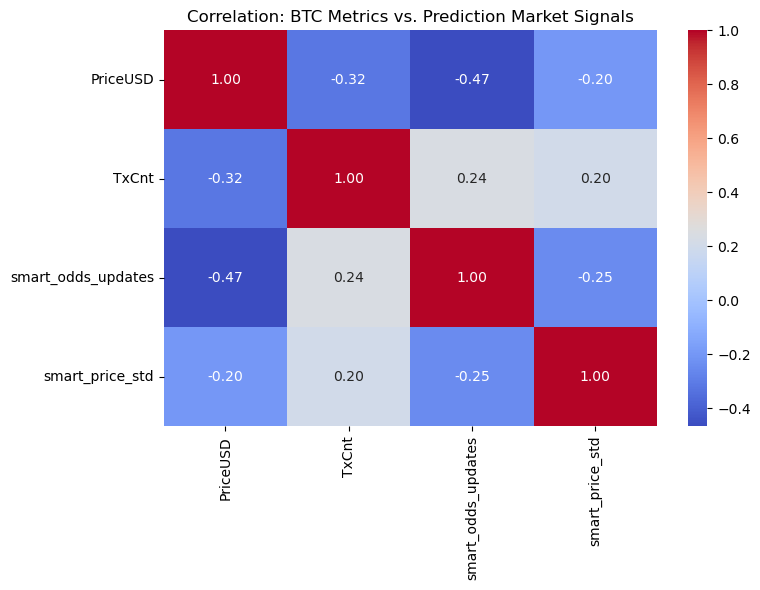

In [20]:

check_cols = [
    'PriceUSD',
    'TxCnt',
    'smart_odds_updates',
    'smart_price_std'
]

corr_matrix = aligned_df[check_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation: BTC Metrics vs. Prediction Market Signals")
plt.tight_layout()
plt.show()


In [21]:
# Returns vs activity
corr_robust = aligned_df['PriceUSD'].pct_change().corr(
    aligned_df['smart_odds_updates']
)
print(f"Correlation (Returns vs Activity): {corr_robust}")

# Volatility vs activity
corr_vol = aligned_df['smart_odds_updates'].corr(
    aligned_df['PriceUSD'].pct_change().abs()
)
print(f"Correlation (Activity vs Volatility): {corr_vol}")


Correlation (Returns vs Activity): 0.04545107235432393
Correlation (Activity vs Volatility): 0.04788559308049942


Correlation (Log Price vs Activity): -0.46711418534557875


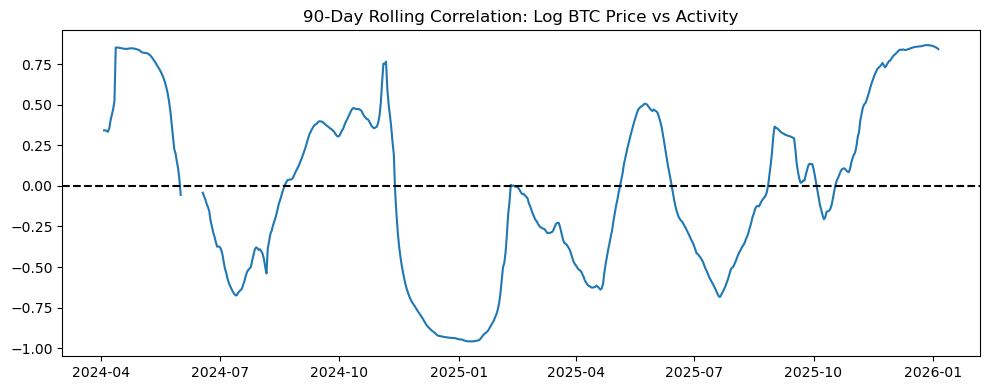

In [22]:
import numpy as np

aligned_df["log_price"] = np.log(aligned_df["PriceUSD"])

corr_log = aligned_df["log_price"].corr(aligned_df["smart_odds_updates"])
print(f"Correlation (Log Price vs Activity): {corr_log}")

rolling_corr = (
    aligned_df["log_price"]
    .rolling(90)
    .corr(aligned_df["smart_odds_updates"])
)

plt.figure(figsize=(10, 4))
plt.plot(rolling_corr)
plt.axhline(0, color="black", linestyle="--")
plt.title("90-Day Rolling Correlation: Log BTC Price vs Activity")
plt.tight_layout()
plt.show()


Key findings:

- Prediction market activity shows a moderate negative correlation (~ −0.47) with Bitcoin price levels.
- Correlations with daily returns and volatility are near zero.
- Rolling correlations indicate persistent regime-level relationships rather than short-term noise.

Interpretation:

Prediction market activity behaves as a counter-cyclical regime signal rather than a short-horizon predictive indicator. Elevated activity tends to occur during lower-price environments and periods of heightened uncertainty.


### 4.3 Accumulation Efficiency Proxy

For accumulation strategies, the goal is not to predict returns, but to improve capital allocation efficiency by allocating more during relatively favorable price environments.

To evaluate whether prediction market activity aligns with such environments, we construct a descriptive proxy:

- Future 30-day minimum price drawdown relative to current price

This measures whether higher activity tends to occur before or during periods with better future buying opportunities.


In [23]:
aligned_df = aligned_df.copy()

aligned_df["future_min_30d"] = (
    aligned_df["PriceUSD"]
    .rolling(window=30, min_periods=1)
    .min()
    .shift(-30)
)

aligned_df["future_drawdown_30d"] = (
    aligned_df["future_min_30d"] / aligned_df["PriceUSD"] - 1
)


In [24]:
aligned_df["activity_quantile"] = pd.qcut(
    aligned_df["smart_odds_updates"],
    q=3,
    labels=["Low Activity", "Medium Activity", "High Activity"]
)

plot_df = aligned_df.dropna(
    subset=["future_drawdown_30d", "activity_quantile"]
)


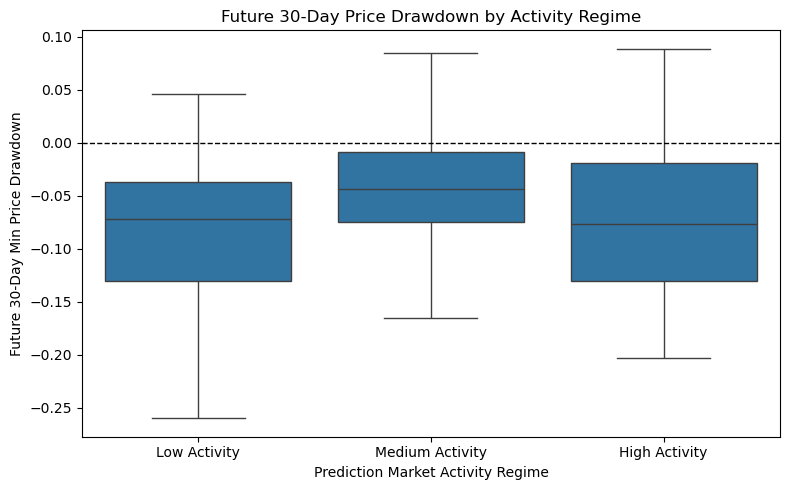

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=plot_df,
    x="activity_quantile",
    y="future_drawdown_30d",
    showfliers=False
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Future 30-Day Price Drawdown by Activity Regime")
plt.xlabel("Prediction Market Activity Regime")
plt.ylabel("Future 30-Day Min Price Drawdown")
plt.tight_layout()
plt.show()


Across all activity regimes, future drawdowns remain predominantly negative, indicating that accumulation opportunities commonly exist regardless of activity level.

Importantly, high prediction market activity does not coincide with systematically worse future buying conditions. In some cases, high-activity regimes exhibit slightly deeper future drawdowns.

Interpretation:

Prediction market activity does not function as a directional return predictor. Instead, it behaves as a contextual regime indicator that may support risk-aware allocation decisions within dynamic accumulation strategies.


## 5. Model-Ready Feature Design & Validation

Having established data integrity, temporal alignment, and exploratory signal relevance, this section outlines how the constructed dataset can be safely transitioned into downstream modeling workflows.

The objective here is not to train or evaluate predictive models. Instead, this section:

- Defines model-ready feature categories
- Specifies time-consistent evaluation splits
- Documents potential leakage risks and mitigation strategies

The intended downstream use case is dynamic, long-only Bitcoin accumulation modeling, where prediction market signals act as contextual conditioning inputs rather than direct return predictors.


### 5.1 Model-Ready Feature Categories

Based on the preceding exploratory analysis, the aligned daily dataset supports three feature categories, each motivated by a distinct role in downstream accumulation modeling.


**1. Bitcoin Market & On-Chain Metrics**

Core daily indicators derived from Coin Metrics, including:

- Price levels
- Transaction activity
- Network usage metrics
- Supply dynamics and exchange flows

These variables provide baseline structural context and serve as primary state features in downstream models.


**2. Aggregated Prediction Market Activity (High-Liquidity Subset)**

Activity- and dispersion-based signals derived from the highest-volume Polymarket markets:

- `smart_odds_updates`
- `smart_price_std`

These features capture market attention, uncertainty, and belief divergence. As shown in Section 4, they exhibit counter-cyclical, regime-level behavior and are treated as contextual conditioning signals.


**3. Contextual Probability Levels (Secondary Features)**

Average probability levels (`smart_mean_price`) provide contextual information about overall market sentiment but are not primary predictive signals due to strong averaging effects across markets.


### 5.2 Temporal Splits & Evaluation Design

Because both Bitcoin and prediction market data are time-series in nature, all downstream modeling must use strictly forward-looking, time-ordered evaluation splits. Random shuffling is explicitly avoided to preserve temporal causality and prevent leakage.

We define a simple chronological split:

- **Train:** earliest 80% of observations (model fitting)
- **Validation:** next 10% (model selection / tuning)
- **Test:** most recent 10% (final held-out evaluation)



In [26]:
# ---- Time-ordered train/val/test split ----
n = len(aligned_df)

train_end = int(n * 0.80)
val_end = int(n * 0.90)

train_df = aligned_df.iloc[:train_end].copy()
val_df = aligned_df.iloc[train_end:val_end].copy()
test_df = aligned_df.iloc[val_end:].copy()

print("Total:", aligned_df.shape)
print("Train:", train_df.shape, "| dates:", train_df.index.min(), "->", train_df.index.max())
print("Val:  ", val_df.shape,   "| dates:", val_df.index.min(),   "->", val_df.index.max())
print("Test: ", test_df.shape,  "| dates:", test_df.index.min(),  "->", test_df.index.max())


Total: (732, 39)
Train: (585, 39) | dates: 2024-01-05 -> 2025-08-11
Val:   (73, 39) | dates: 2025-08-12 -> 2025-10-23
Test:  (74, 39) | dates: 2025-10-24 -> 2026-01-05


### 5.3 Leakage & Look-Ahead Risk Assessment

Several potential sources of leakage were explicitly considered and mitigated:


- All prediction market features are constructed using same-day information only and do not incorporate future odds updates.

- Timestamp normalization ensures that prediction market events are aligned strictly by calendar date, preventing inadvertent inclusion of intra-day future information.

- Forward-looking quantities (e.g., future drawdowns) are computed using explicit temporal shifts and are never included as input features.

- Aggregation is performed at a daily level, reducing microstructure noise and minimizing implicit look-ahead bias.


### 5.4 Readiness Summary

The resulting dataset consists of temporally aligned, leakage-aware daily features spanning Bitcoin market metrics and high-liquidity prediction market activity.

While no predictive claims are made at this stage, the dataset is structurally suitable for downstream modeling, regime analysis, and decision-support experimentation in later project phases.

In particular, prediction market activity signals demonstrate potential value as contextual conditioning inputs within volatility-aware, long-only Bitcoin accumulation frameworks.


## 6. Modeling Experiments

### 6.1 Baseline – Uniform DCA

As a reference benchmark, we first consider a standard uniform Dollar-Cost Averaging (DCA) strategy, in which capital is allocated evenly across all time periods. This approach makes no attempt to time the market or incorporate external information, and therefore serves as a neutral baseline for evaluating more advanced allocation strategies.

Uniform DCA is widely regarded as a robust accumulation method in volatile assets such as Bitcoin because of its simplicity, transparency, and resistance to overfitting. Accordingly, any dynamic strategy proposed in this study must demonstrate consistent outperformance relative to this benchmark in order to justify its additional complexity.

In [33]:
!python -m template.backtest_template

Validating strategy submission readiness...

 Windows where strategy underperformed Uniform DCA:
                          dynamic_percentile  uniform_percentile     Delta
window                                                                    
2018-10-27 -> 2019-10-27           41.979515           42.184367 -0.204851
2018-10-29 -> 2019-10-29           41.805001           42.070124 -0.265122
2018-10-30 -> 2019-10-30           42.007191           42.011404 -0.004213
2018-10-31 -> 2019-10-31           41.881028           41.953332 -0.072304
2018-11-01 -> 2019-11-01           41.548311           41.894946 -0.346635
...                                      ...                 ...       ...
2024-09-08 -> 2025-09-08           28.345757           28.747581 -0.401824
2024-09-09 -> 2025-09-09           30.451677           30.699404 -0.247726
2024-09-10 -> 2025-09-10           30.543384           30.718194 -0.174810
2024-09-11 -> 2025-09-11           30.354380           30.463686 -0.109306
202

2026-03-16 17:27:10 INFO     Starting Bitcoin DCA Strategy Analysis
2026-03-16 17:27:10 INFO     Loading CoinMetrics BTC data from local file: C:\Users\chen5\Documents\bitcoin-analytics-capstone\data\Coin Metrics\coinmetrics_btc.csv
2026-03-16 17:27:10 WARNING  Missing BTC-USD prices for 1 dates from 2018-01-01 to 2026-01-14. First missing date: 2026-01-14
2026-03-16 17:27:10 INFO     Loaded CoinMetrics data: 6221 rows, 2009-01-03 to 2026-01-14
2026-03-16 17:27:10 INFO     Precomputing features...
2026-03-16 17:27:10 INFO     Running SPD backtest for 'Dynamic DCA'...
2026-03-16 17:27:10 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-03-16 17:28:10 INFO      Validated weight sums for 2557 windows (all sum to 1.0)
2026-03-16 17:28:10 INFO     Aggregated Metrics for Dynamic DCA:
2026-03-16 17:28:10 INFO       SPD: min=1004.32, max=20313.77, mean=6673.19, median=3939.56
2026-03-16 17:28:10 INFO       Percentile: min=17.63%, max=73.04%, mean=39.74%, medi

### 6.2 Baseline Model – Results & Analysis

The 200-day moving average (MA) strategy delivers a modest but consistent improvement over uniform DCA. Across 2,557 rolling windows, the model achieves a win rate of 61.05%, exceeding the 50% benchmark, while reaching a Final Model Score of 51.74%. These results indicate that a simple trend-following rule can provide a stable edge in long-term Bitcoin accumulation.

In terms of efficiency, the strategy produces a mean excess percentile of +1.04% and a relative improvement of approximately 2.61%, suggesting that the MA-based allocation is directionally helpful but not transformative. The dynamic-to-uniform ratio remains close to 1.03, reinforcing the interpretation that the gains are incremental rather than dramatic.

This outcome is consistent with expectations for a trend-following accumulation strategy. The 200-day MA captures broad market cycles and increases allocation during drawdowns, which aligns naturally with long-only DCA objectives. At the same time, the limited magnitude of improvement highlights an important constraint: price-based trend signals alone may not provide enough informational advantage to materially outperform a simple accumulation benchmark.

Overall, this baseline is both strong and reliable, and therefore sets a meaningful bar for later models. Any additional signal, including Polymarket-derived features, must demonstrate value beyond this already robust trend-following framework.

### 6.3 Model v1: Naive Signal-Driven DCA

In [8]:
!python -m template.backtest_template

Validating strategy submission readiness...

 Windows where strategy underperformed Uniform DCA:
                          dynamic_percentile  uniform_percentile     Delta
window                                                                    
2018-06-22 -> 2019-06-22           45.617463           45.723495 -0.106032
2018-06-23 -> 2019-06-23           45.744970           45.866166 -0.121196
2018-06-24 -> 2019-06-24           46.068725           46.207643 -0.138918
2018-06-25 -> 2019-06-25           47.157345           47.431388 -0.274043
2018-06-26 -> 2019-06-26           48.558840           49.013770 -0.454930
...                                      ...                 ...       ...
2024-12-27 -> 2025-12-27           35.270498           38.502195 -3.231697
2024-12-28 -> 2025-12-28           35.582159           38.544250 -2.962091
2024-12-29 -> 2025-12-29           36.037686           38.596036 -2.558350
2024-12-30 -> 2025-12-30           35.747521           38.628726 -2.881206
202

2026-04-11 13:35:31 INFO     Starting Bitcoin DCA Strategy Analysis
2026-04-11 13:35:31 INFO     Loading CoinMetrics BTC data from local file: C:\Users\chen5\Documents\bitcoin-analytics-capstone\data\Coin Metrics\coinmetrics_btc.csv
2026-04-11 13:35:31 WARNING  Missing BTC-USD prices for 1 dates from 2018-01-01 to 2026-01-14. First missing date: 2026-01-14
2026-04-11 13:35:31 INFO     Loaded CoinMetrics data: 6221 rows, 2009-01-03 to 2026-01-14
2026-04-11 13:35:31 INFO     Precomputing features...
2026-04-11 13:35:31 INFO     Loading Polymarket data: finance_politics_markets.parquet
2026-04-11 13:35:32 INFO       Loaded 78321 rows from finance_politics_markets.parquet
2026-04-11 13:35:32 INFO     Loading Polymarket data: finance_politics_tokens.parquet
2026-04-11 13:35:32 INFO       Loaded 156636 rows from finance_politics_tokens.parquet
2026-04-11 13:35:32 INFO     Loading Polymarket data: finance_politics_trades.parquet
2026-04-11 13:39:07 WARNING  Failed to load finance_politics_tra

In the first extension beyond the baseline, Polymarket-derived features are incorporated directly into the allocation process through a composite signal. This version combines market activity, dispersion, and price-trend information into a single signal that continuously adjusts DCA weights.

The results show that this direct signal integration performs poorly. The model achieves a win rate of only 44.70%, failing to meet the minimum 50% threshold, and its Final Model Score drops to 40.07%. This represents a substantial decline relative to both uniform DCA and the moving-average baseline.

This outcome suggests that Polymarket-derived signals do not function well as direct trading inputs. While these features may contain some information about market context, their relationship with Bitcoin accumulation is too weak and unstable to support continuous allocation adjustments. Instead of improving decisions, the model appears to amplify noise.

Overall, this version serves as an important negative result. It shows that simply adding external signals is not sufficient, and that signal integration must be more selective and better controlled.

### 6.4 Model v1.2: Stabilized Signal Integration

In [9]:
!python -m template.backtest_template

Validating strategy submission readiness...

 Windows where strategy underperformed Uniform DCA:
                          dynamic_percentile  uniform_percentile     Delta
window                                                                    
2018-06-17 -> 2019-06-17           42.494573           42.497930 -0.003357
2018-06-20 -> 2019-06-20           42.945217           42.963879 -0.018662
2018-06-21 -> 2019-06-21           44.272130           44.382317 -0.110186
2018-06-22 -> 2019-06-22           45.524414           45.723495 -0.199081
2018-06-23 -> 2019-06-23           45.657382           45.866166 -0.208785
...                                      ...                 ...       ...
2024-10-05 -> 2025-10-05           27.215360           27.649812 -0.434452
2024-10-06 -> 2025-10-06           27.625391           28.102145 -0.476754
2024-10-07 -> 2025-10-07           27.726473           27.857298 -0.130825
2024-10-08 -> 2025-10-08           27.388489           27.605603 -0.217114
202

2026-04-11 13:53:52 INFO     Starting Bitcoin DCA Strategy Analysis
2026-04-11 13:53:52 INFO     Loading CoinMetrics BTC data from local file: C:\Users\chen5\Documents\bitcoin-analytics-capstone\data\Coin Metrics\coinmetrics_btc.csv
2026-04-11 13:53:52 WARNING  Missing BTC-USD prices for 1 dates from 2018-01-01 to 2026-01-14. First missing date: 2026-01-14
2026-04-11 13:53:52 INFO     Loaded CoinMetrics data: 6221 rows, 2009-01-03 to 2026-01-14
2026-04-11 13:53:52 INFO     Precomputing features...
2026-04-11 13:53:52 INFO     Loading Polymarket data: finance_politics_markets.parquet
2026-04-11 13:53:53 INFO       Loaded 78321 rows from finance_politics_markets.parquet
2026-04-11 13:53:53 INFO     Loading Polymarket data: finance_politics_tokens.parquet
2026-04-11 13:53:53 INFO       Loaded 156636 rows from finance_politics_tokens.parquet
2026-04-11 13:53:53 INFO     Loading Polymarket data: finance_politics_trades.parquet
2026-04-11 13:57:59 INFO       Fixing corrupted timestamps in co

To address the instability of the naive signal-driven model, the next version introduces a more controlled formulation in which the composite signal is transformed and bounded before affecting allocations. This design reduces the influence of extreme values and aims to make Polymarket inputs less noisy and more stable over time.

This modification produces a clear recovery in performance. The model reaches a win rate of 54.32% and a Final Model Score of 50.71%, moving back above the minimum threshold and substantially improving on Model v1. However, it still remains below the moving-average baseline.

The improvement indicates that the main problem in Model v1 was not the mere presence of external signals, but the way they were used. Once signal magnitude is constrained, performance becomes much more stable. At the same time, the fact that the model does not outperform the baseline suggests that signal stabilization alone is not enough to extract meaningful additional value.

Overall, this version can be viewed as a partial success: it resolves the worst instability of the naive model, but does not yet provide a convincing advantage over a strong trend-following benchmark.

### 6.5 Model v2: Conservative Overlay

In [10]:
!python -m template.backtest_template

Validating strategy submission readiness...

 Windows where strategy underperformed Uniform DCA:
                          dynamic_percentile  uniform_percentile     Delta
window                                                                    
2018-10-27 -> 2019-10-27           41.924659           42.184367 -0.259708
2018-10-28 -> 2019-10-28           42.078895           42.128021 -0.049126
2018-10-29 -> 2019-10-29           41.781568           42.070124 -0.288556
2018-10-30 -> 2019-10-30           41.951826           42.011404 -0.059578
2018-10-31 -> 2019-10-31           41.846335           41.953332 -0.106998
...                                      ...                 ...       ...
2024-11-06 -> 2025-11-06           36.474795           36.728025 -0.253230
2024-11-07 -> 2025-11-07           36.710521           36.882648 -0.172127
2024-11-08 -> 2025-11-08           37.046073           37.174470 -0.128397
2024-11-09 -> 2025-11-09           36.908050           36.985472 -0.077422
202

2026-04-11 14:12:25 INFO     Starting Bitcoin DCA Strategy Analysis
2026-04-11 14:12:25 INFO     Loading CoinMetrics BTC data from local file: C:\Users\chen5\Documents\bitcoin-analytics-capstone\data\Coin Metrics\coinmetrics_btc.csv
2026-04-11 14:12:25 WARNING  Missing BTC-USD prices for 1 dates from 2018-01-01 to 2026-01-14. First missing date: 2026-01-14
2026-04-11 14:12:25 INFO     Loaded CoinMetrics data: 6221 rows, 2009-01-03 to 2026-01-14
2026-04-11 14:12:25 INFO     Precomputing features...
2026-04-11 14:12:25 INFO     Loading Polymarket data: finance_politics_markets.parquet
2026-04-11 14:12:25 INFO       Loaded 78321 rows from finance_politics_markets.parquet
2026-04-11 14:12:25 INFO     Loading Polymarket data: finance_politics_tokens.parquet
2026-04-11 14:12:26 INFO       Loaded 156636 rows from finance_politics_tokens.parquet
2026-04-11 14:12:26 INFO     Loading Polymarket data: finance_politics_trades.parquet
2026-04-11 14:16:11 INFO       Fixing corrupted timestamps in co

The next iteration adopts a more conservative design in which the moving-average signal remains the primary driver of allocation decisions, while Polymarket-derived inputs are used only as a mild overlay. Rather than allowing external signals to dominate the allocation rule, this version constrains their role to small adjustments around an already stable baseline.

This approach improves consistency relative to earlier signal-driven models, achieving a win rate of 57.45%. However, its Final Model Score is 48.45%, which remains below both the moving-average baseline and the stabilized v1.2 version.

These results highlight an important trade-off. By limiting the role of Polymarket signals, the model avoids the severe degradation observed in the naive formulation. At the same time, the overlay becomes so weak that it contributes only limited additional value. In other words, this design improves robustness, but does so partly by sacrificing the model’s ability to meaningfully enhance performance.

Overall, this version represents a useful intermediate step. It confirms that Polymarket signals should not be used aggressively, but it also shows that an overly cautious integration strategy is unlikely to outperform a strong baseline. This motivates a more structured approach in which external signals are used conditionally rather than continuously.

### 6.6 Model v3: Early Regime-Conditional Strategy

In [11]:
!python -m template.backtest_template

Validating strategy submission readiness...

 Windows where strategy underperformed Uniform DCA:
                          dynamic_percentile  uniform_percentile     Delta
window                                                                    
2018-11-04 -> 2019-11-04           41.347720           41.720509 -0.372790
2018-11-05 -> 2019-11-05           41.299255           41.664319 -0.365064
2018-11-06 -> 2019-11-06           41.059514           41.607318 -0.547804
2018-11-07 -> 2019-11-07           41.088394           41.553323 -0.464929
2018-11-09 -> 2019-11-09           41.349559           41.457710 -0.108151
...                                      ...                 ...       ...
2024-09-18 -> 2025-09-18           30.975597           31.505886 -0.530289
2024-09-19 -> 2025-09-19           30.893553           31.259732 -0.366179
2024-09-20 -> 2025-09-20           30.781807           31.027285 -0.245477
2024-09-21 -> 2025-09-21           30.634191           30.797165 -0.162973
202

2026-04-11 14:34:07 INFO     Starting Bitcoin DCA Strategy Analysis
2026-04-11 14:34:07 INFO     Loading CoinMetrics BTC data from local file: C:\Users\chen5\Documents\bitcoin-analytics-capstone\data\Coin Metrics\coinmetrics_btc.csv
2026-04-11 14:34:07 WARNING  Missing BTC-USD prices for 1 dates from 2018-01-01 to 2026-01-14. First missing date: 2026-01-14
2026-04-11 14:34:07 INFO     Loaded CoinMetrics data: 6221 rows, 2009-01-03 to 2026-01-14
2026-04-11 14:34:07 INFO     Precomputing features...
C:\Users\chen5\Documents\bitcoin-analytics-capstone\template\regime_conditional_dca_v1.py:291: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = price.pct_change()
2026-04-11 14:34:10 INFO     Loading Polymarket data: finance_politics_markets.parquet
2026-04-11 14:34:10 INFO       Loaded 783

To move beyond continuous signal integration, the next set of models adopts a regime-conditional framework. In this formulation, the moving-average trend signal remains the primary driver of allocation decisions, while Polymarket-derived inputs are introduced only when market conditions make them potentially informative. In particular, external signals are emphasized when the baseline trend signal is weak or ambiguous, rather than being applied uniformly across all periods.

The first regime-based version achieves a win rate of 60.19% and a Final Model Score of 50.78%. This represents a clear improvement over the earlier signal-driven models and confirms that conditional signal usage is more effective than continuous integration. At the same time, performance remains slightly below the moving-average baseline.

This result suggests that the central value of Polymarket signals lies not in their direct predictive power, but in their ability to provide incremental information under specific market conditions. By restricting their use to more relevant regimes, the model avoids much of the noise amplification seen in earlier versions.

Overall, this version marks an important conceptual step forward. It shows that the key modeling challenge is not whether to use external signals, but how to use them selectively and in combination with a stronger core trend signal.

### 6.7 Model v3.1: Percentile-Based Regime-Conditional Strategy

In [12]:
!python -m template.backtest_template

Validating strategy submission readiness...

 Windows where strategy underperformed Uniform DCA:
                          dynamic_percentile  uniform_percentile     Delta
window                                                                    
2018-11-04 -> 2019-11-04           41.425485           41.720509 -0.295024
2018-11-05 -> 2019-11-05           41.375559           41.664319 -0.288760
2018-11-06 -> 2019-11-06           41.109899           41.607318 -0.497419
2018-11-07 -> 2019-11-07           41.135692           41.553323 -0.417630
2018-11-09 -> 2019-11-09           41.391853           41.457710 -0.065857
...                                      ...                 ...       ...
2024-09-16 -> 2025-09-16           29.768038           30.033019 -0.264981
2024-09-17 -> 2025-09-17           31.516663           31.764662 -0.247999
2024-09-18 -> 2025-09-18           31.315404           31.505886 -0.190482
2024-09-19 -> 2025-09-19           31.104442           31.259732 -0.155290
202

2026-04-11 14:52:52 INFO     Starting Bitcoin DCA Strategy Analysis
2026-04-11 14:52:52 INFO     Loading CoinMetrics BTC data from local file: C:\Users\chen5\Documents\bitcoin-analytics-capstone\data\Coin Metrics\coinmetrics_btc.csv
2026-04-11 14:52:52 WARNING  Missing BTC-USD prices for 1 dates from 2018-01-01 to 2026-01-14. First missing date: 2026-01-14
2026-04-11 14:52:52 INFO     Loaded CoinMetrics data: 6221 rows, 2009-01-03 to 2026-01-14
2026-04-11 14:52:52 INFO     Precomputing features...
C:\Users\chen5\Documents\bitcoin-analytics-capstone\template\regime_conditional_dca_v2.py:166: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = price.pct_change()
2026-04-11 14:52:55 INFO     Loading Polymarket data: finance_politics_markets.parquet
2026-04-11 14:52:55 INFO       Loaded 783

Building on the initial regime-based formulation, the next version introduces a smoother percentile-based transformation of Polymarket signals. Instead of relying on sharper or more discrete activation rules, this approach converts signal inputs into rolling percentiles, allowing external information to enter the allocation rule in a more gradual and adaptive manner. The moving-average signal still determines the overall direction, while Polymarket features act as a secondary, conditionally activated overlay.

This version delivers the strongest performance among all tested models. It achieves a win rate of 60.74% and a Final Model Score of 51.90%, exceeding both the moving-average baseline (51.74%) and all previous signal-driven or regime-based variants.

The improvement indicates that smoother signal integration is more effective than either naive continuous usage or overly rigid activation. By allowing weak external signals to influence allocation gradually, the model extracts incremental value without overwhelming the core trend-following structure.

Overall, this percentile-based regime-conditional model represents the best balance between responsiveness and robustness. It is therefore selected as the final model for this study.

### 6.8 Model v3.2: More Aggressive Regime Variant

In [13]:
!python -m template.backtest_template

Validating strategy submission readiness...

 Windows where strategy underperformed Uniform DCA:
                          dynamic_percentile  uniform_percentile     Delta
window                                                                    
2018-11-04 -> 2019-11-04           41.478755           41.720509 -0.241754
2018-11-05 -> 2019-11-05           41.431142           41.664319 -0.233178
2018-11-06 -> 2019-11-06           41.157683           41.607318 -0.449635
2018-11-07 -> 2019-11-07           41.181058           41.553323 -0.372265
2018-11-09 -> 2019-11-09           41.424489           41.457710 -0.033221
...                                      ...                 ...       ...
2024-09-17 -> 2025-09-17           31.370549           31.764662 -0.394112
2024-09-18 -> 2025-09-18           31.134398           31.505886 -0.371488
2024-09-19 -> 2025-09-19           30.898084           31.259732 -0.361648
2024-09-20 -> 2025-09-20           30.835238           31.027285 -0.192046
202

2026-04-11 15:11:39 INFO     Starting Bitcoin DCA Strategy Analysis
2026-04-11 15:11:39 INFO     Loading CoinMetrics BTC data from local file: C:\Users\chen5\Documents\bitcoin-analytics-capstone\data\Coin Metrics\coinmetrics_btc.csv
2026-04-11 15:11:40 WARNING  Missing BTC-USD prices for 1 dates from 2018-01-01 to 2026-01-14. First missing date: 2026-01-14
2026-04-11 15:11:40 INFO     Loaded CoinMetrics data: 6221 rows, 2009-01-03 to 2026-01-14
2026-04-11 15:11:40 INFO     Precomputing features...
2026-04-11 15:11:42 INFO     Loading Polymarket data: finance_politics_markets.parquet
2026-04-11 15:11:43 INFO       Loaded 78321 rows from finance_politics_markets.parquet
2026-04-11 15:11:43 INFO     Loading Polymarket data: finance_politics_tokens.parquet
2026-04-11 15:11:43 INFO       Loaded 156636 rows from finance_politics_tokens.parquet
2026-04-11 15:11:43 INFO     Loading Polymarket data: finance_politics_trades.parquet
2026-04-11 15:15:19 INFO       Fixing corrupted timestamps in co

As a robustness check, a more aggressive regime-based variant is also evaluated. This version increases the influence of Polymarket-derived inputs within the same overall regime-conditional framework, testing whether stronger external signal usage can generate additional improvement.

The model remains competitive, achieving a win rate of 60.38% and a Final Model Score of 51.84%. However, it does not outperform the percentile-based regime model, which remains slightly better at 51.90%.

This result reinforces an important pattern observed throughout the modeling experiments: increasing the strength of external signals does not necessarily improve performance. Once signal usage becomes too aggressive, some of the stability gained through selective integration begins to erode.

Overall, this variant is useful as a robustness test rather than as the final model. It confirms that balanced, controlled integration is preferable to stronger but less stable signal amplification.

### 6.9 Model Comparison and Final Model Selection


Comparing all model variants reveals a clear progression in the experimentation process. The naive signal-driven model performs worst, showing that direct use of Polymarket signals introduces substantial noise. The stabilized and conservative signal-driven variants improve robustness, but still fail to outperform the moving-average baseline in a meaningful way.

The strongest results emerge from the regime-conditional family of models. These formulations treat external information as context-dependent rather than continuously predictive, and therefore integrate Polymarket inputs only when they are most likely to be informative. Among them, the percentile-based regime-conditional model achieves the best overall performance, with a Final Model Score of 51.90% and a win rate of 60.74%.

Although the moving-average baseline still achieves a slightly higher win rate (61.05%), the percentile-based regime model attains the highest overall score, indicating a better balance between consistency and cumulative performance.

Based on these results, the percentile-based regime-conditional model (v2) is selected as the final model. Its advantage lies not in making external signals dominant, but in integrating them selectively, smoothly, and within a risk-controlled framework. This makes it the most effective and most interpretable strategy among the models tested.

In [20]:
!python -m template.backtest_template

Validating strategy submission readiness...

 Windows where strategy underperformed Uniform DCA:
                          dynamic_percentile  uniform_percentile     Delta
window                                                                    
2018-11-04 -> 2019-11-04           41.425485           41.720509 -0.295024
2018-11-05 -> 2019-11-05           41.375559           41.664319 -0.288760
2018-11-06 -> 2019-11-06           41.109899           41.607318 -0.497419
2018-11-07 -> 2019-11-07           41.135692           41.553323 -0.417630
2018-11-09 -> 2019-11-09           41.391853           41.457710 -0.065857
...                                      ...                 ...       ...
2024-09-16 -> 2025-09-16           29.768038           30.033019 -0.264981
2024-09-17 -> 2025-09-17           31.516663           31.764662 -0.247999
2024-09-18 -> 2025-09-18           31.315404           31.505886 -0.190482
2024-09-19 -> 2025-09-19           31.104442           31.259732 -0.155290
202

2026-04-12 13:41:58 INFO     Starting Bitcoin DCA Strategy Analysis
2026-04-12 13:41:58 INFO     Loading CoinMetrics BTC data from local file: C:\Users\chen5\Documents\bitcoin-analytics-capstone\data\Coin Metrics\coinmetrics_btc.csv
2026-04-12 13:41:58 WARNING  Missing BTC-USD prices for 1 dates from 2018-01-01 to 2026-01-14. First missing date: 2026-01-14
2026-04-12 13:41:58 INFO     Loaded CoinMetrics data: 6221 rows, 2009-01-03 to 2026-01-14
2026-04-12 13:41:58 INFO     Precomputing features...
C:\Users\chen5\Documents\bitcoin-analytics-capstone\template\regime_conditional_dca_v2.py:166: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = price.pct_change()
2026-04-12 13:42:01 INFO     Loading Polymarket data: finance_politics_markets.parquet
2026-04-12 13:42:02 INFO       Loaded 783

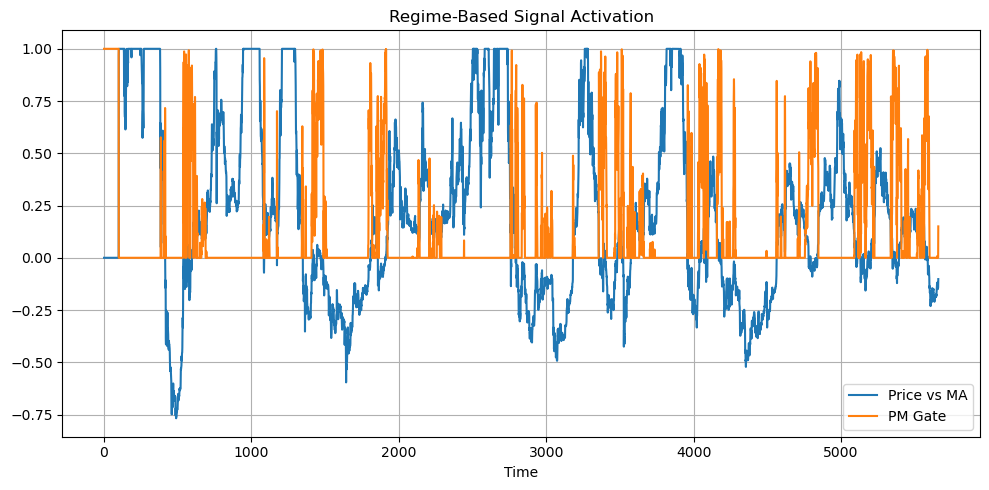

In [22]:
import numpy as np
import matplotlib.pyplot as plt

price_vs_ma = np.load("output/price_vs_ma.npy")
pm_gate = np.load("output/pm_gate.npy")

plt.figure(figsize=(10,5))
plt.plot(price_vs_ma, label="Price vs MA")
plt.plot(pm_gate, label="PM Gate")

plt.title("Regime-Based Signal Activation")
plt.xlabel("Time")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Interpretation

The PM gate is higher when the price is close to its moving average and lower when the price deviates strongly from the trend. This indicates that the model selectively activates Polymarket signals in periods of trend uncertainty, while relying more on the moving average signal when the trend is strong.

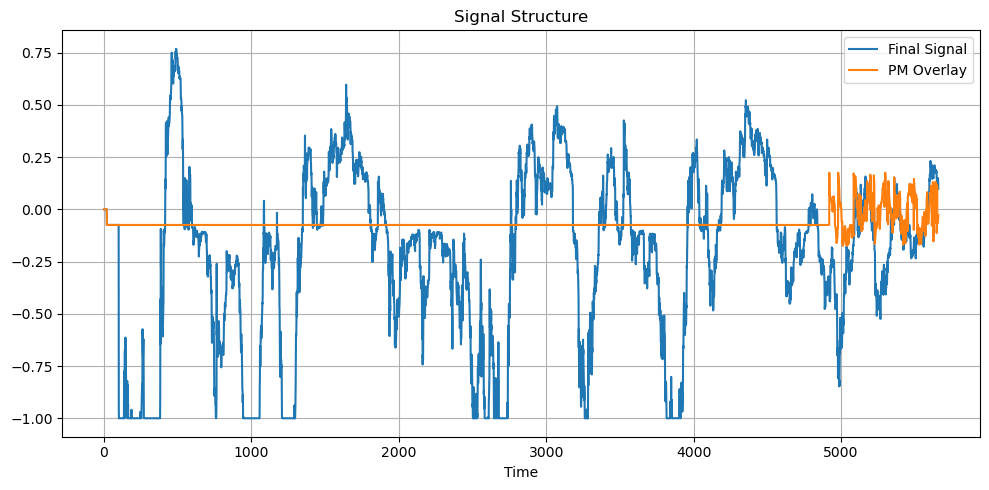

In [23]:
pm_overlay = np.load("output/pm_overlay.npy")
signal = np.load("output/signal_raw.npy")

plt.figure(figsize=(10,5))
plt.plot(signal, label="Final Signal")
plt.plot(pm_overlay, label="PM Overlay")

plt.title("Signal Structure")
plt.xlabel("Time")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Interpretation

The final signal is primarily driven by the moving average component, while the Polymarket overlay contributes relatively small adjustments. This suggests that external signals are used in a controlled manner and do not dominate the allocation decisions.

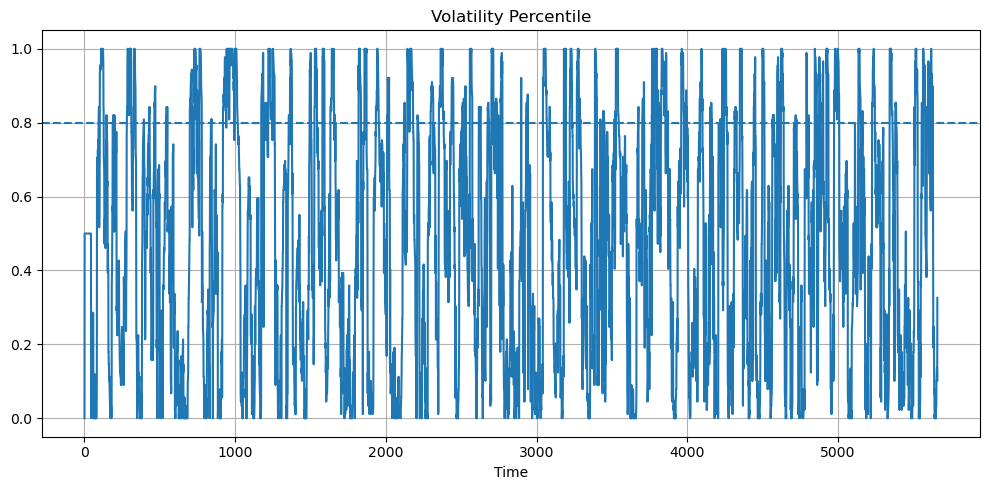

In [24]:
vol = np.load("output/vol_pct.npy")

plt.figure(figsize=(10,5))
plt.plot(vol)

plt.axhline(0.8, linestyle="--")

plt.title("Volatility Percentile")
plt.xlabel("Time")
plt.grid()

plt.tight_layout()
plt.show()

### Interpretation

The volatility percentile fluctuates over time, with some periods exceeding the threshold where signal dampening is applied. This shows that the model actively reduces exposure during high-volatility regimes, improving robustness.

### Summary

These plots confirm that the model behaves as intended:
- Polymarket signals are applied selectively through the gating mechanism  
- The moving average remains the dominant driver of the signal  
- Risk is controlled via volatility-based dampening  

Overall, the model integrates external signals in a balanced and context-aware manner.

## 7. Conclusion and Final Insights

This study evaluates whether Polymarket-derived signals can improve a long-only Bitcoin DCA strategy beyond a strong moving-average baseline. The overall results show that external signals do contain useful information, but that this information is weak, noisy, and highly context-dependent. As a result, model performance depends far more on how these signals are incorporated than on their standalone predictive strength.

The experimental sequence reveals a clear pattern. Direct signal-driven integration performs poorly, indicating that Polymarket features are not effective as continuous trading signals. Stabilized and conservative variants improve robustness, but still provide limited gains. The strongest performance emerges only after adopting a regime-conditional framework, in which Polymarket signals are introduced selectively when the primary trend signal is weak or ambiguous.

Among all tested variants, the percentile-based regime-conditional model delivers the best overall performance, achieving the highest Final Model Score while preserving strong consistency across rolling windows. This suggests that the most effective use of external market information is not to replace a strong baseline, but to act as a controlled secondary input within a broader trend-following structure.

More broadly, the findings suggest an important modeling principle for long-term allocation strategies: weak behavioral or sentiment-based signals can add value, but only when used selectively, smoothly, and under explicit risk control. In this project, the key improvement does not come from amplifying Polymarket signals, but from constraining them to the regimes in which they are most likely to be informative.

Overall, the final model demonstrates that modest but meaningful gains can be achieved through regime-aware integration of external signals. While the improvement over the baseline remains incremental rather than dramatic, the results provide a strong and interpretable case for using Polymarket information as a conditional overlay in long-term Bitcoin accumulation.

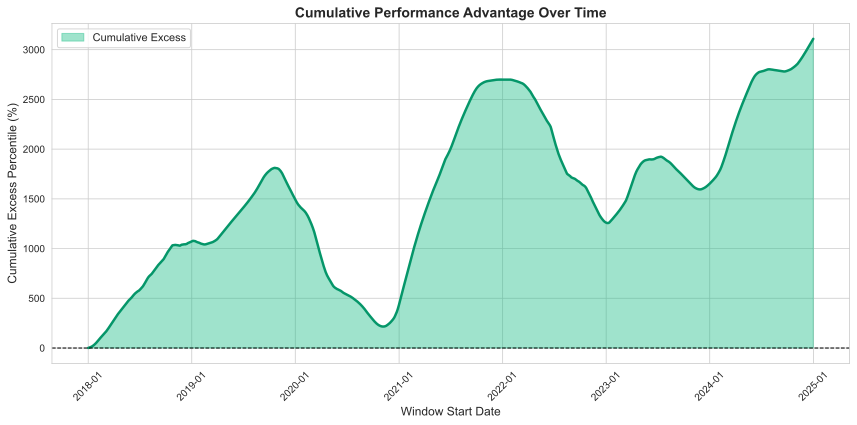

In [27]:
from IPython.display import SVG, display

display(SVG("output/cumulative_performance.svg"))

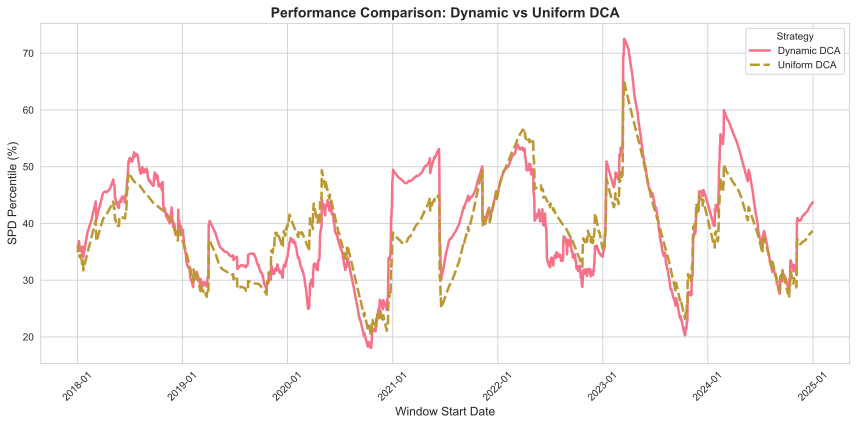

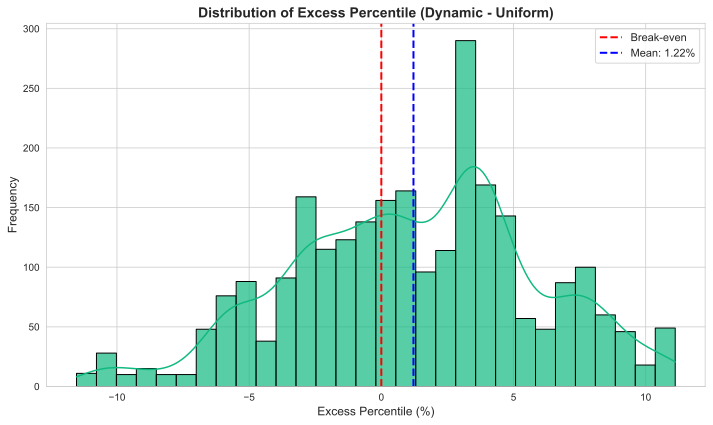

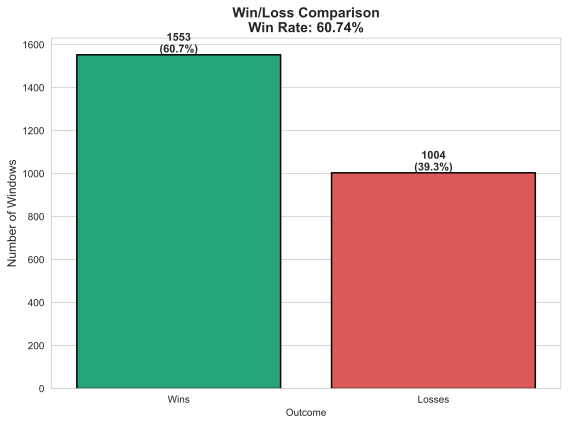

In [26]:
from IPython.display import SVG, display

display(SVG("output/performance_comparison.svg"))
display(SVG("output/excess_percentile_distribution.svg"))
display(SVG("output/win_loss_comparison.svg"))

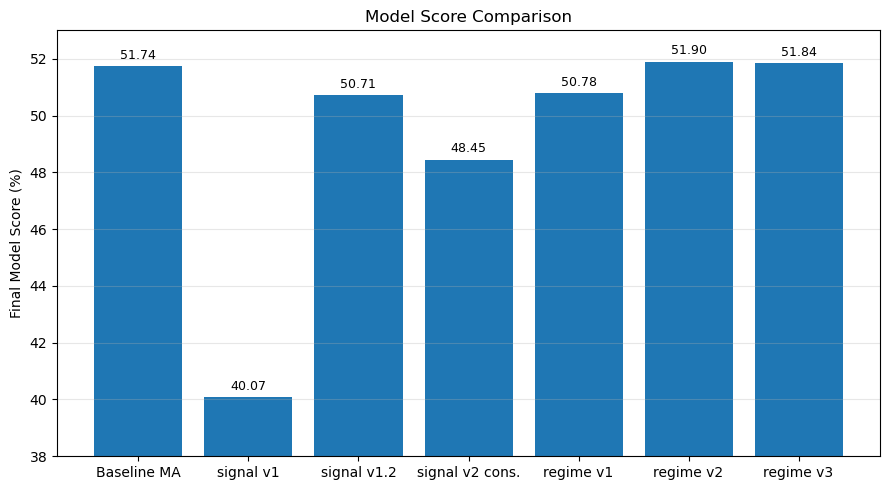

In [29]:
import matplotlib.pyplot as plt

models = [
    "Baseline MA",
    "signal v1",
    "signal v1.2",
    "signal v2 cons.",
    "regime v1",
    "regime v2",
    "regime v3"
]

scores = [51.74, 40.07, 50.71, 48.45, 50.78, 51.90, 51.84]

plt.figure(figsize=(9, 5))
bars = plt.bar(models, scores)

plt.title("Model Score Comparison")
plt.ylabel("Final Model Score (%)")
plt.ylim(38, 53)

for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.15,
        f"{score:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

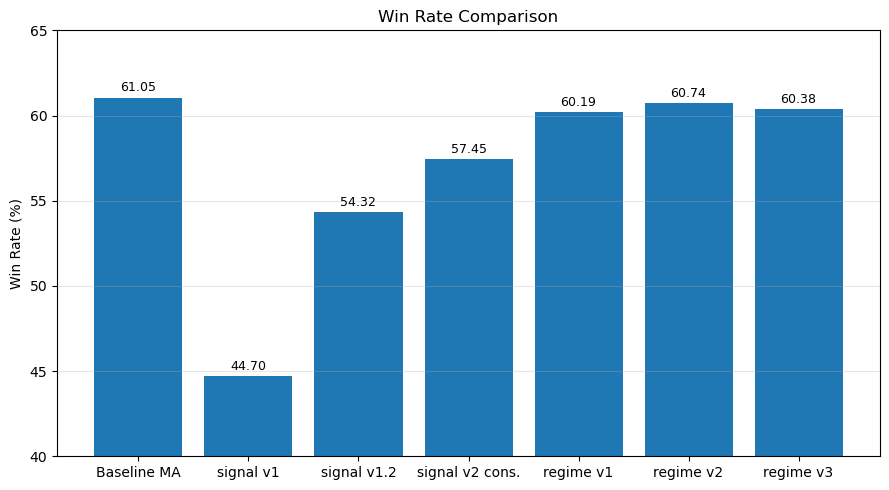

In [30]:
import matplotlib.pyplot as plt

models = [
    "Baseline MA",
    "signal v1",
    "signal v1.2",
    "signal v2 cons.",
    "regime v1",
    "regime v2",
    "regime v3"
]

win_rates = [61.05, 44.70, 54.32, 57.45, 60.19, 60.74, 60.38]

plt.figure(figsize=(9, 5))
bars = plt.bar(models, win_rates)

plt.title("Win Rate Comparison")
plt.ylabel("Win Rate (%)")
plt.ylim(40, 65)

for bar, wr in zip(bars, win_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        wr + 0.2,
        f"{wr:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The comparison shows a clear progression across model iterations. The naive signal-driven model performs worst, confirming that direct use of Polymarket signals introduces noise. Performance recovers after stabilization and improves further in the regime-based models. Among all tested variants, the percentile-based regime-conditional model (v2) achieves the highest Final Model Score, making it the best final model choice.